In [50]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 

In [2]:
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer

In [3]:
df = pd.read_csv(r"C:\Users\asifb\OneDrive\Desktop\Python language\Jupyter Notebook\Kaggle\Titanic-Dataset.csv")
df = df[["Age" , "Fare" , "SibSp" , "Parch" , "Survived"]]
df

,Age,Fare,SibSp,Parch,Survived
0,22.0,7.2500,1,0,0
1,38.0,71.2833,1,0,1
2,26.0,7.9250,0,0,1
3,35.0,53.1000,1,0,1
4,35.0,8.0500,0,0,0
...,...,...,...,...,...
886,27.0,13.0000,0,0,0
887,19.0,30.0000,0,0,1
888,NaN,23.4500,1,2,0
889,26.0,30.0000,0,0,1


In [4]:
df["Family"] = df["SibSp"] + df["Parch"]
df.drop(columns = ["SibSp" , "Parch"], inplace = True)
df

,Age,Fare,Survived,Family
0,22.0,7.2500,0,1
1,38.0,71.2833,1,1
2,26.0,7.9250,1,0
3,35.0,53.1000,1,1
4,35.0,8.0500,0,0
...,...,...,...,...
886,27.0,13.0000,0,0
887,19.0,30.0000,1,0
888,NaN,23.4500,0,3
889,26.0,30.0000,1,0


In [5]:
cols = [c for c in df.columns if c != 'Survived'] + ['Survived']
df = df[cols]
df.head()

,Age,Fare,Family,Survived
0,22.0,7.2500,1,0
1,38.0,71.2833,1,1
2,26.0,7.9250,0,1
3,35.0,53.1000,1,1
4,35.0,8.0500,0,0


In [6]:
df.isnull().mean()

Age         0.198653
Fare        0.000000
Family      0.000000
Survived    0.000000
dtype: float64

In [7]:
X = df.iloc[:,0:3]
y = df.iloc[:,-1]

In [8]:
X_train , X_test , y_train , y_test = train_test_split(X , y , test_size = 0.25 , random_state = 42)

In [9]:
X_train.shape , X_test.shape

((668, 3), (223, 3))

In [10]:
Mean_age = df["Age"].mean()
Median_age = df["Age"].median()

In [11]:
X_train["Age_Mean"] = X_train["Age"].fillna(Mean_age)
X_train["Age_Median"] = X_train["Age"].fillna(Median_age)
X_train.head()

,Age,Fare,Family,Age_Mean,Age_Median
298,NaN,30.5000,0,29.699118,28.00
884,25.00,7.0500,0,25.000000,25.00
247,24.00,14.5000,2,24.000000,24.00
478,22.00,7.5208,0,22.000000,22.00
305,0.92,151.5500,3,0.920000,0.92


In [12]:
X_train["Age"].var()

np.float64(211.00497090249686)

In [13]:
print(X_train["Age_Mean"].var())# varriance shrink as more values are now closer to mean
print(X_train["Age_Median"].var())

169.25911810454718
169.56766573719128


In [14]:
X_train.cov()

,Age,Fare,Family,Age_Mean,Age_Median
Age,211.004971,76.431548,-6.643668,211.004971,211.004971
Fare,76.431548,2662.974063,18.947195,60.637125,64.726516
Family,-6.643668,18.947195,2.865676,-5.333592,-5.304762
Age_Mean,211.004971,60.637125,-5.333592,169.259118,169.184171
Age_Median,211.004971,64.726516,-5.304762,169.184171,169.567666


<Axes: >

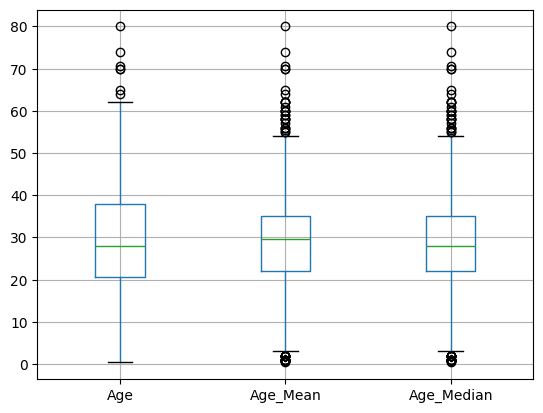

In [15]:
X_train[["Age" , "Age_Mean" , "Age_Median"]].boxplot()

In [16]:
X_train.head()

,Age,Fare,Family,Age_Mean,Age_Median
298,NaN,30.5000,0,29.699118,28.00
884,25.00,7.0500,0,25.000000,25.00
247,24.00,14.5000,2,24.000000,24.00
478,22.00,7.5208,0,22.000000,22.00
305,0.92,151.5500,3,0.920000,0.92


In [18]:
Age_SI = SimpleImputer(strategy = "mean")
Age_SIM = SimpleImputer(strategy = "median")

In [23]:
X_train["Age_SI"] = Age_SI.fit_transform(X_train[["Age"]])

In [27]:
X_train["Age_SIM"]= Age_SIM.fit_transform(X_train[["Age"]])
X_train.head()

,Age,Fare,Family,Age_Mean,Age_Median,Age_SI,Age_SIM
298,NaN,30.5000,0,29.699118,28.00,29.421343,28.00
884,25.00,7.0500,0,25.000000,25.00,25.000000,25.00
247,24.00,14.5000,2,24.000000,24.00,24.000000,24.00
478,22.00,7.5208,0,22.000000,22.00,22.000000,22.00
305,0.92,151.5500,3,0.920000,0.92,0.920000,0.92


### Arbitrary Value Imputation 

In [29]:
df.head()

,Age,Fare,Family,Survived
0,22.0,7.2500,1,0
1,38.0,71.2833,1,1
2,26.0,7.9250,0,1
3,35.0,53.1000,1,1
4,35.0,8.0500,0,0


In [32]:
df["Age 99"] = df["Age"].fillna(99)


In [34]:
SIM = SimpleImputer(strategy = "constant" , fill_value = 99)
df["SIM Age 99"] = SIM.fit_transform(df[["Age"]])
df.head()

,Age,Fare,Family,Survived,Age 99,SIM Age 99
0,22.0,7.2500,1,0,22.0,22.0
1,38.0,71.2833,1,1,38.0,38.0
2,26.0,7.9250,0,1,26.0,26.0
3,35.0,53.1000,1,1,35.0,35.0
4,35.0,8.0500,0,0,35.0,35.0


In [35]:
mask = np.random.rand(len(df)) < 0.1
df.loc[mask, 'Family'] = np.nan

In [44]:
df = pd.read_csv(r"C:\Users\asifb\OneDrive\Desktop\Python language\Jupyter Notebook\Kaggle\Train Data .csv" , usecols = ["GarageQual" , "FireplaceQu" , "SalePrice"] )
df.head()

,FireplaceQu,GarageQual,SalePrice
0,NaN,TA,208500
1,TA,TA,181500
2,TA,TA,223500
3,Gd,TA,140000
4,TA,TA,250000


In [45]:
df.isnull().mean()*100

FireplaceQu    47.260274
GarageQual      5.547945
SalePrice       0.000000
dtype: float64

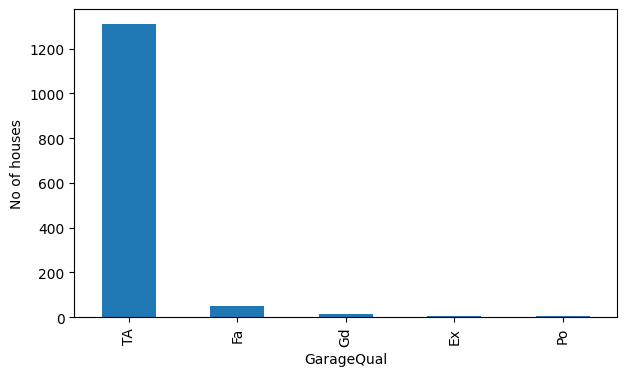

In [56]:
plt.figure(figsize =(7,4))
df["GarageQual"].value_counts().sort_values(ascending = False).plot(kind= "bar")
plt.xlabel("GarageQual")
plt.ylabel("No of houses")
plt.show()

In [57]:
df["GarageQual"].mode()

0    TA
Name: GarageQual, dtype: str